In [1]:
import os
import pandas as pd 
import tempfile 
import zipfile
actual_file = []
main_path = "/mnt/c/Users/rajes/Desktop/cortland"

if os.path.exists(main_path):
    for zip_file in os.listdir(main_path):
        if zip_file.endswith(".zip"):
            with tempfile.TemporaryDirectory() as temp_dir:
                try:
                    with zipfile.ZipFile(os.path.join(main_path, zip_file), "r") as zf:
                        zf.extractall(temp_dir)
                        for root, dirs, files in os.walk(temp_dir):
                            for d in dirs:
                                if d.startswith('Processed'):
                                    sec_path = os.path.join(root, d)
                                    for f in os.listdir(sec_path):
                                        if f.endswith(('.xls', '.xlsx')):
                                            actual_file.append(pd.read_excel(os.path.join(sec_path, f)))
                except Exception as e: print(f"Error: {e}")
    if actual_file: df_raw = pd.concat(actual_file)

In [6]:
df_raw['behavioral_category'].unique()

array(['Standing', 'Walking', 'Grazing', 'Standing and Ruminating',
       'GreenFeed', 'Lying and Ruminating', 'Lying', 'Drinking',
       'Browsing'], dtype=object)

In [7]:
df_raw.shape

(2450933, 8)

In [20]:
map_dict={'Standing and Ruminating': 'Standing', 'Drinking':'Standing', 'Lying and Ruminating':'Lying', 'Browsing':'Grazing'}

In [21]:
type(list(map_dict.keys()))

list

In [22]:
df_raw['behavioral_category']= df_raw['behavioral_category'].apply(lambda x : map_dict[x] if x in list(map_dict.keys()) else x)

In [15]:
df_raw= df_raw[df_raw['behavioral_category']!='GreenFeed']

<Axes: xlabel='behavioral_category'>

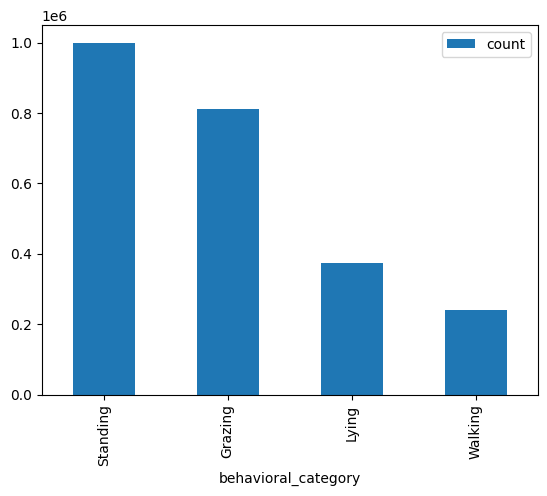

In [23]:
df_raw.behavioral_category.value_counts().reset_index().plot(x='behavioral_category', y='count', kind='bar')

 TOTAL NUMBER OF ANIMALS: 7



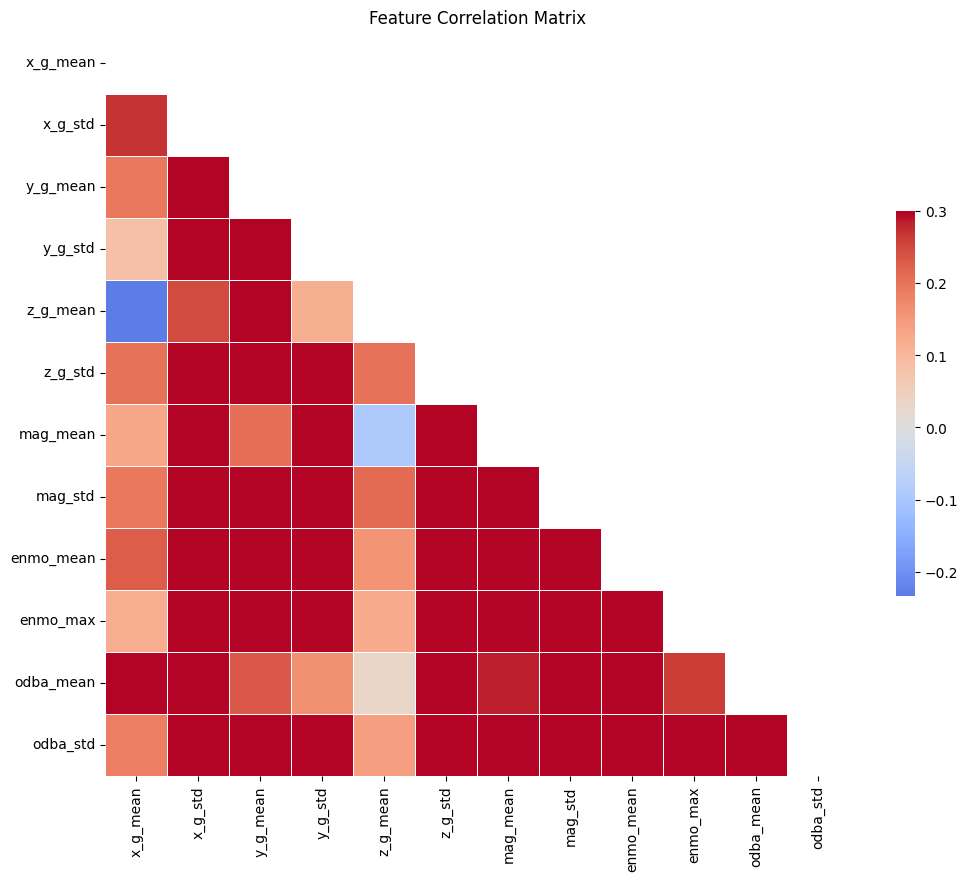

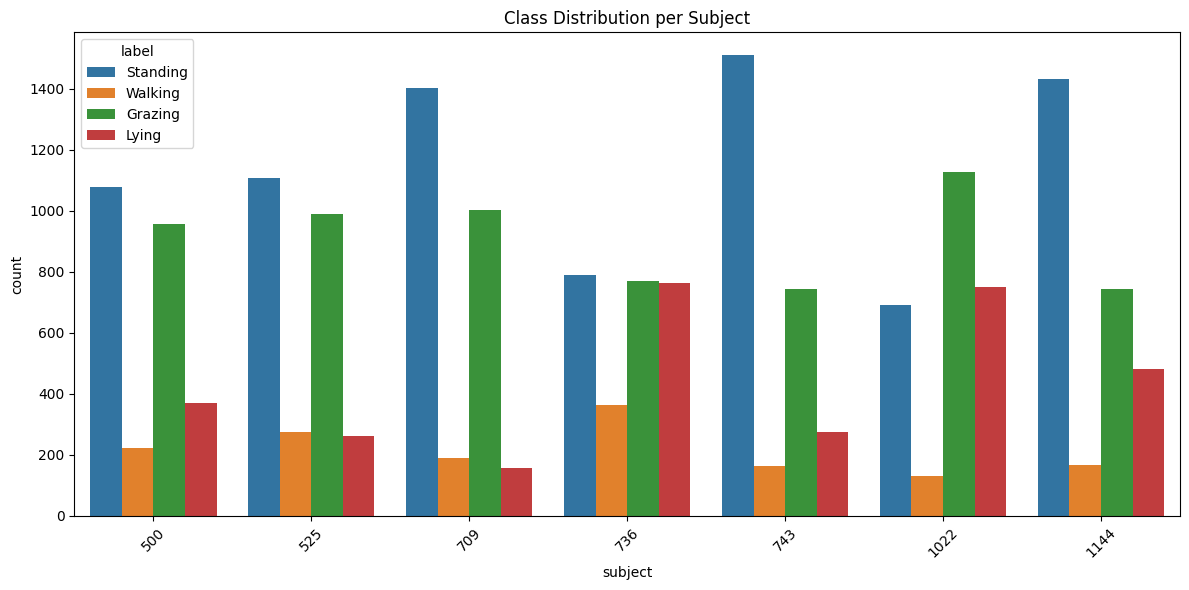


--- Training LSTM ---
Starting LOSO for LSTM on 7 subjects...
Overall LSTM Results:
(0.7205979189200159, 0.6397837159856586, 0.6506492372944537, None)


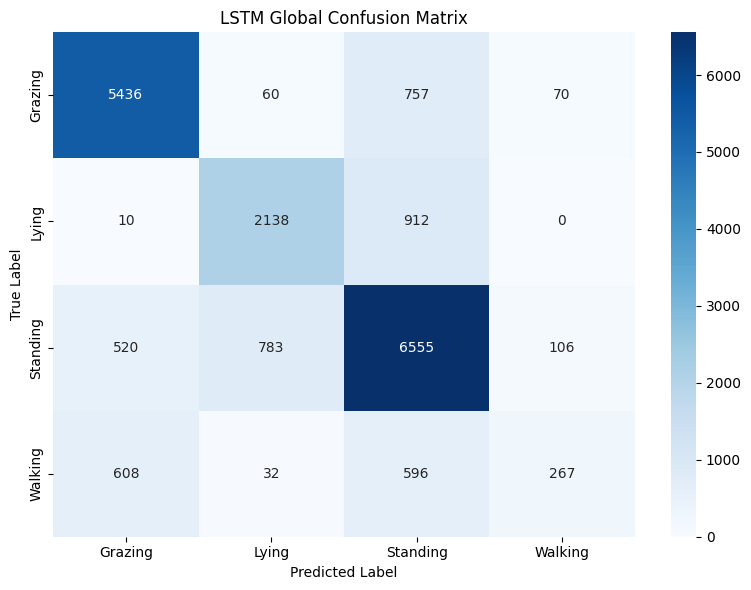


--- Plotting Individual Confusion Matrices (Best & Worst 2) ---


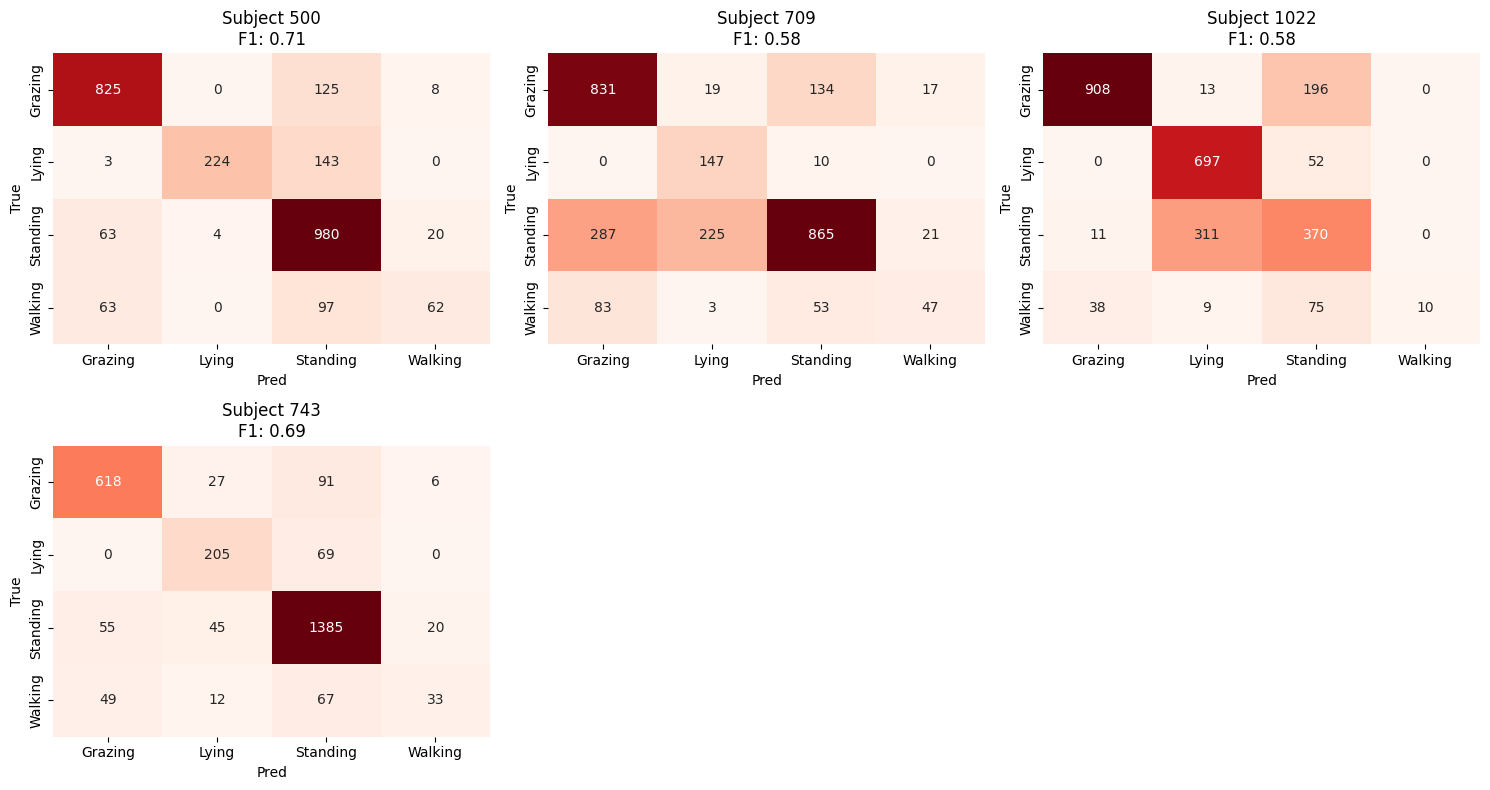


--- Training BiLSTM ---
Starting LOSO for BiLSTM on 7 subjects...
Overall BiLSTM Results:
(0.7200982974156198, 0.6362900908574295, 0.6512278686128892, None)


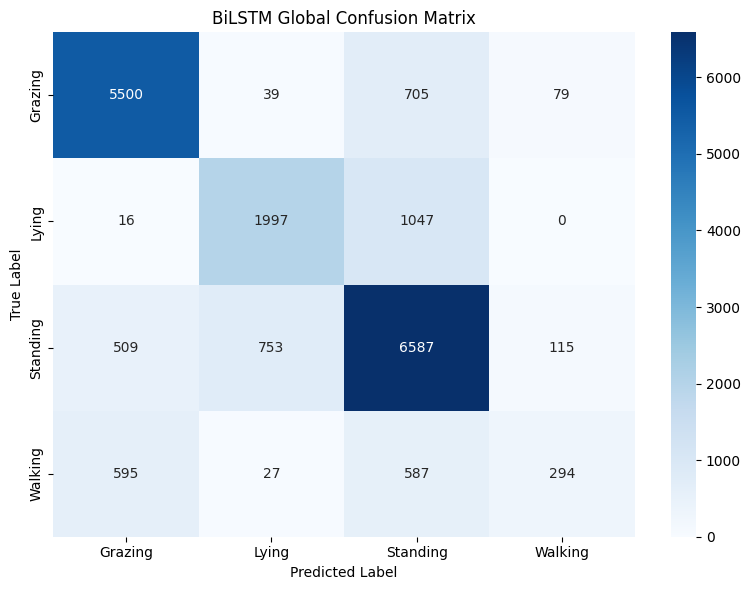


--- Plotting Individual Confusion Matrices (Best & Worst 2) ---


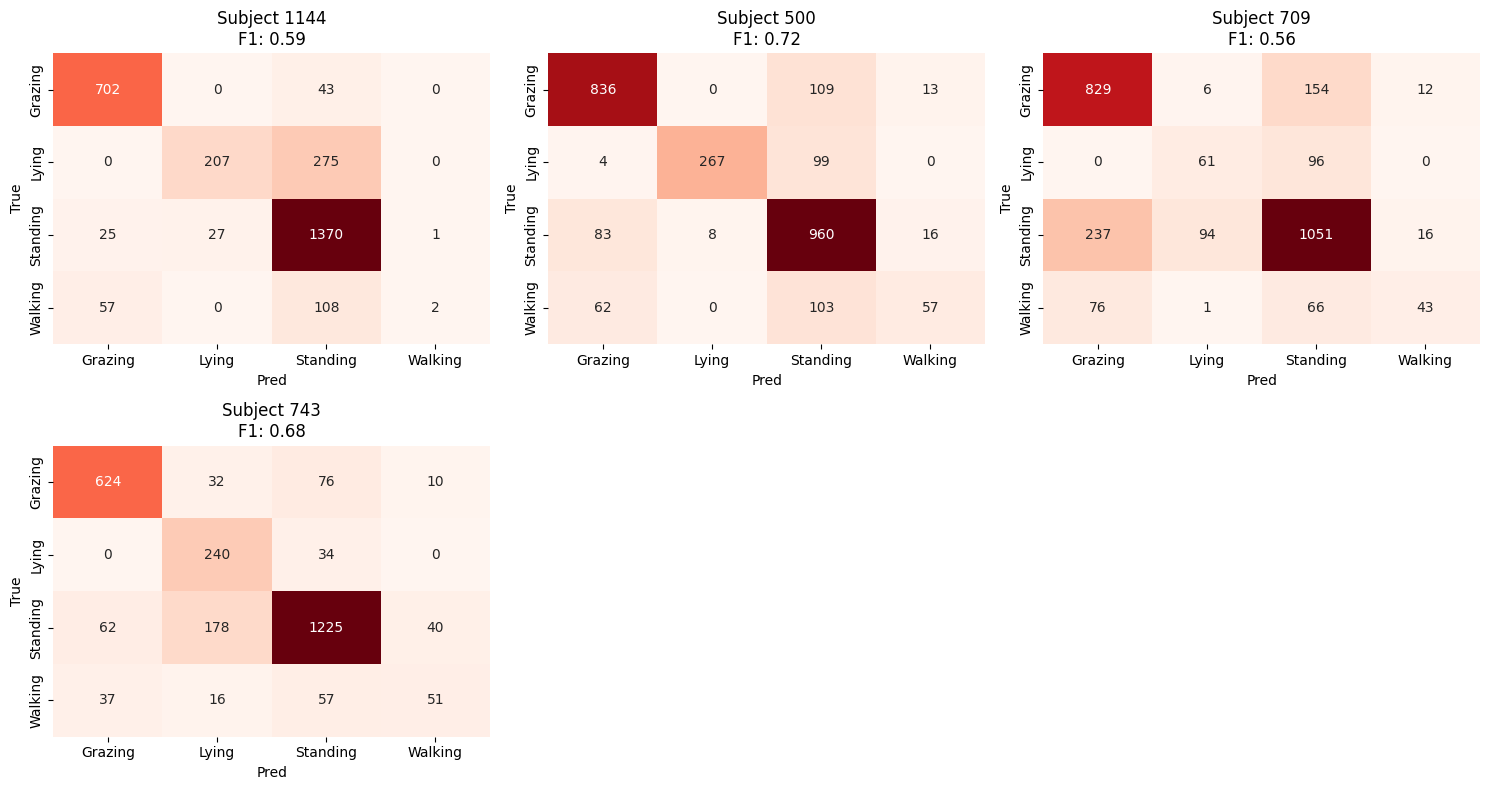


--- Training RNN ---
Starting LOSO for RNN on 7 subjects...
Overall RNN Results:
(0.7254012506493213, 0.6583176758797807, 0.671256594510612, None)


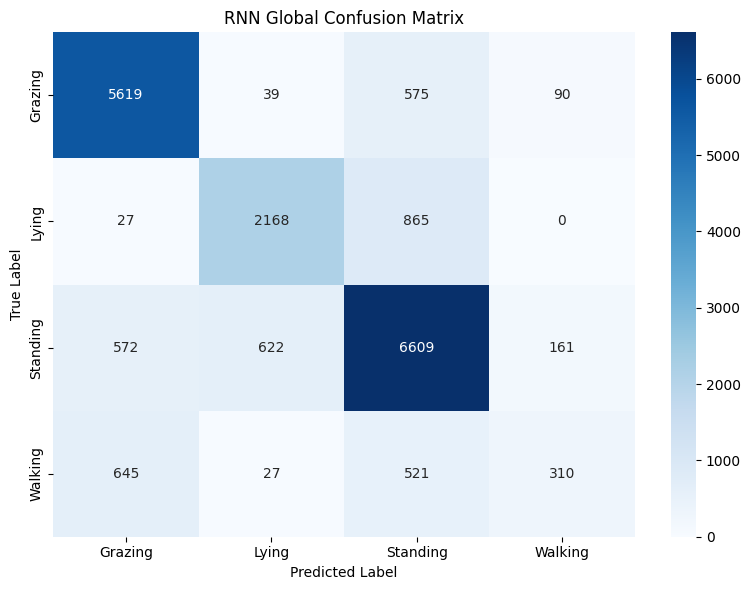


--- Plotting Individual Confusion Matrices (Best & Worst 2) ---


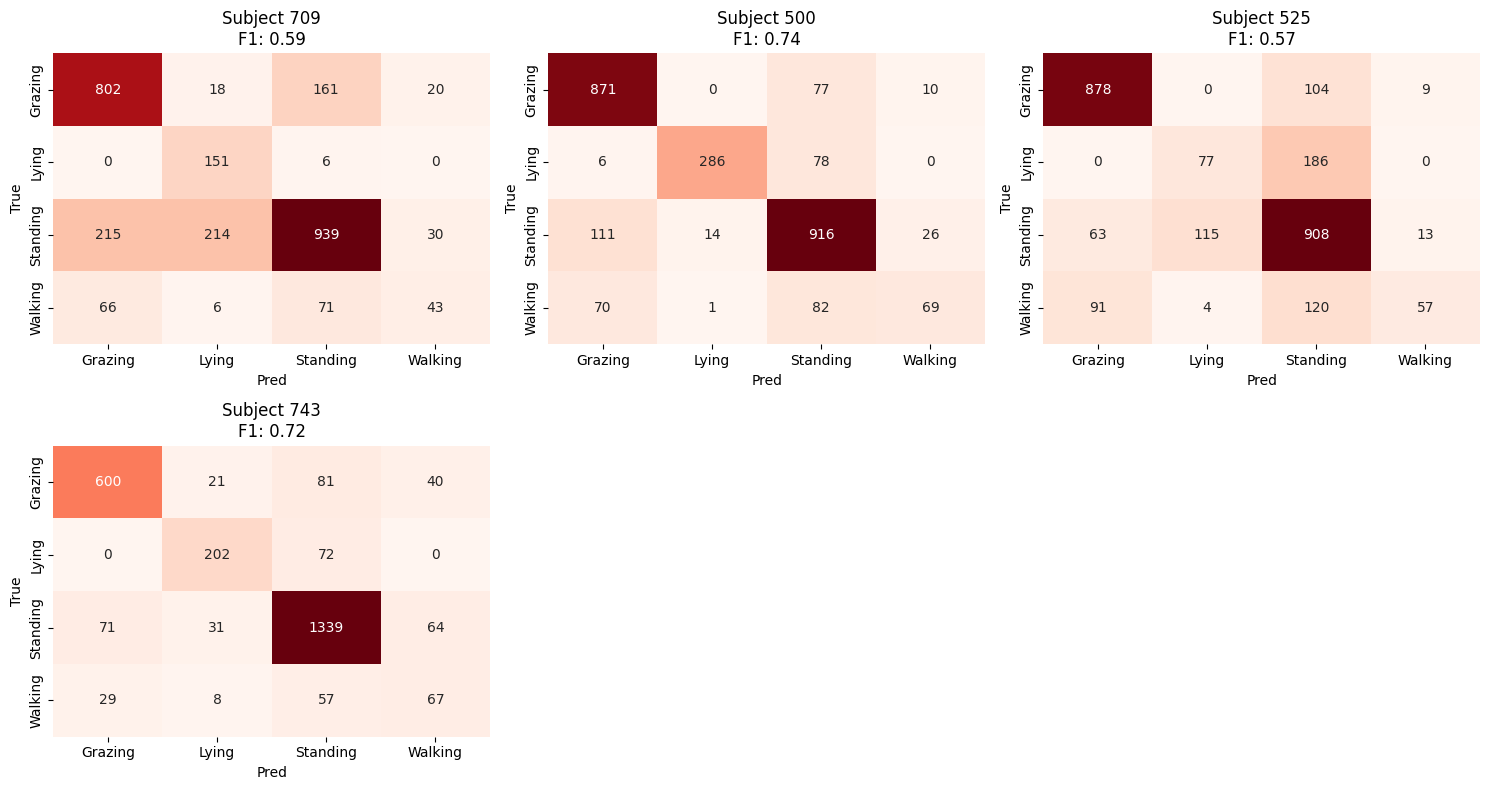

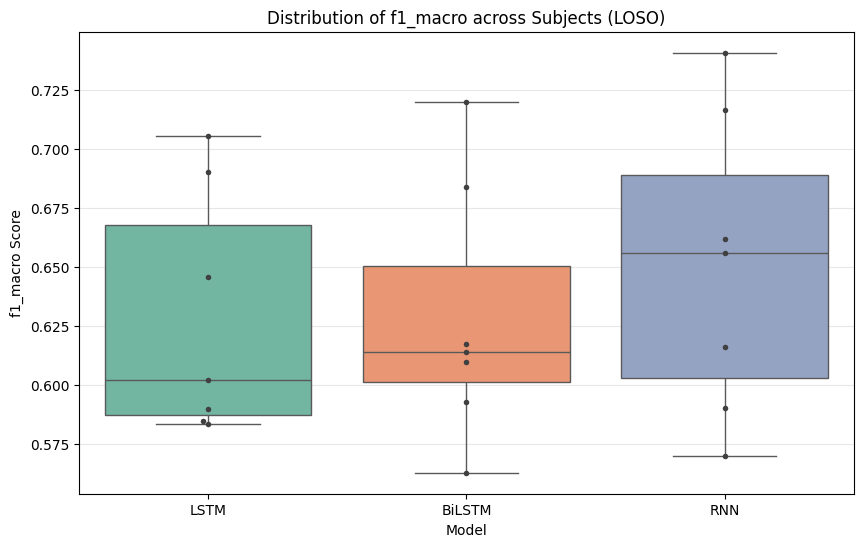

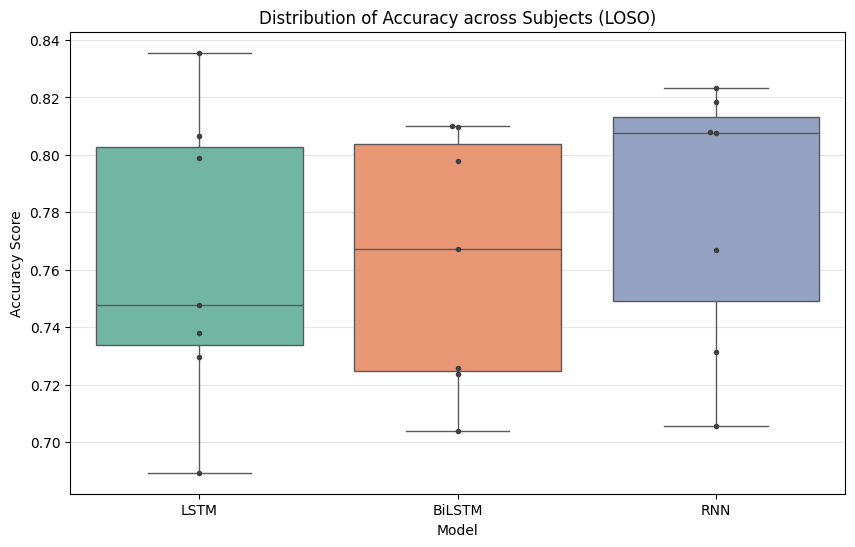

In [26]:
# =====================================================
# IMPORTS
# =====================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score, f1_score
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

# =====================================================
# 1. PIPELINE
# =====================================================
class AdaptiveAccelPipeline:
    def __init__(self, df):
        self.df = df.copy()
        self.df["local_ts"] = pd.to_datetime(self.df["local_ts"])
        self.df = self.df.sort_values(["subject", "local_ts"])

    def filter(self, cutoff=5.0):
        def f(g):
            dt = g["local_ts"].diff().dt.total_seconds()
            dt = dt[dt > 0]
            if len(dt) < 10:
                return g
            fs = 1 / dt.median()
            nyq = fs * 0.5
            if fs <= cutoff * 2:
                return g
            b, a = butter(4, cutoff / nyq, btype="low")
            for c in ["x", "y", "z"]:
                g[c] = filtfilt(b, a, g[c])
            return g
        self.df = self.df.groupby("subject", group_keys=False).apply(f)

    def features(self):
        scale = 16384
        self.df["x_g"] = self.df["x"] / scale
        self.df["y_g"] = self.df["y"] / scale
        self.df["z_g"] = self.df["z"] / scale
        self.df["mag"] = np.sqrt(
            self.df["x_g"]**2 +
            self.df["y_g"]**2 +
            self.df["z_g"]**2
        )
        self.df["enmo"] = np.maximum(self.df["mag"] - 1, 0)
        self.df["odba"] = (
            (self.df["x_g"] - self.df["x_g"].mean()).abs() +
            (self.df["y_g"] - self.df["y_g"].mean()).abs() +
            (self.df["z_g"] - self.df["z_g"].mean()).abs()
        )

    def resample(self, window=10, thresh=0.7):
        def labeler(x):
            vc = x.value_counts(normalize=True)
            if len(vc) and vc.iloc[0] >= thresh:
                return vc.index[0]
            return np.nan

        agg = {
            "x_g": ["mean", "std"],
            "y_g": ["mean", "std"],
            "z_g": ["mean", "std"],
            "mag": ["mean", "std"],
            "enmo": ["mean", "max"],
            "odba": ["mean", "std"],
            "behavioral_category": labeler
        }

        out = (
            self.df.set_index("local_ts")
            .groupby("subject")
            .resample(f"{window}s")
            .agg(agg)
        )

        out.columns = [f"{a}_{b}" if b else a for a, b in out.columns]
        out = out.rename(columns={"behavioral_category_labeler": "label"})
        return out.dropna(subset=["label"]).reset_index()

    def sequences(self, df, feats, target, steps):
        X, y, s = [], [], []
        for sub, g in df.groupby("subject"):
            g = g.sort_values("local_ts")
            if len(g) <= steps:
                continue
            for i in range(len(g) - steps):
                X.append(g[feats].values[i:i+steps])
                y.append(g[target].iloc[i+steps])
                s.append(sub)
        return np.array(X), np.array(y), np.array(s)

# =====================================================
# 2. MODELS
# =====================================================
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, classes):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim,
            batch_first=True, bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class TransformerModel(nn.Module):
    def __init__(self, input_dim, heads, layers, classes):
        super().__init__()
        enc = nn.TransformerEncoderLayer(
            d_model=input_dim,
            nhead=heads,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc, layers)
        self.fc = nn.Linear(input_dim, classes)

    def forward(self, x):
        x = self.encoder(x)
        return self.fc(x[:, -1, :])

# =====================================================
# 3. UPDATED LOSO TRAINING
# =====================================================
def run_loso(X, y, subjects, le, model_type):

    all_true, all_pred = [], []
    
    # Store metrics per subject for detailed visualization
    subject_results = {
        "subject": [], 
        "accuracy": [], 
        "f1_macro": [], 
        "y_true": [], 
        "y_pred": []
    }

    unique_subjects = np.unique(subjects)
    print(f"Starting LOSO for {model_type} on {len(unique_subjects)} subjects...")

    for test_subject in unique_subjects:

        tr = subjects != test_subject
        te = subjects == test_subject

        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        if len(np.unique(ytr)) < 2:
            continue

        train_loader = DataLoader(
            TensorDataset(torch.tensor(Xtr).float(), torch.tensor(ytr)),
            batch_size=32, shuffle=True
        )
        test_loader = DataLoader(
            TensorDataset(torch.tensor(Xte).float(), torch.tensor(yte)),
            batch_size=32
        )

        # Model instantiation
        input_dim = X.shape[2]
        num_classes = len(le.classes_)
        
        if model_type == "RNN":
            model = RNNModel(input_dim, 64, num_classes)
        elif model_type == "LSTM":
            model = LSTMModel(input_dim, 64, num_classes)
        elif model_type == "BiLSTM":
            model = BiLSTMModel(input_dim, 64, num_classes)
        else:
            model = TransformerModel(input_dim, 4, 2, num_classes)

        model.to(device)
        opt = optim.Adam(model.parameters(), lr=0.001)
        loss_fn = nn.CrossEntropyLoss()

        best_loss = np.inf
        best_wts = copy.deepcopy(model.state_dict())
        patience, p = 5, 0

        # Quick Training Loop
        for epoch in range(15): # Reduced epochs for demo speed
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                opt.step()

            # Validation on the LOOCV fold
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += loss_fn(model(xb), yb).item()
            
            if val_loss < best_loss:
                best_loss = val_loss
                best_wts = copy.deepcopy(model.state_dict())
                p = 0
            else:
                p += 1
                if p >= patience:
                    break

        model.load_state_dict(best_wts)
        model.eval()

        preds = []
        with torch.no_grad():
            for xb, _ in test_loader:
                xb = xb.to(device)
                preds.extend(torch.argmax(model(xb), 1).cpu().numpy())

        # Accumulate Global Results
        all_true.extend(yte)
        all_pred.extend(preds)

        # Accumulate Per-Subject Results
        acc = accuracy_score(yte, preds)
        f1 = f1_score(yte, preds, average='macro')
        
        subject_results["subject"].append(test_subject)
        subject_results["accuracy"].append(acc)
        subject_results["f1_macro"].append(f1)
        subject_results["y_true"].append(yte)
        subject_results["y_pred"].append(np.array(preds))

    return np.array(all_true), np.array(all_pred), subject_results

# =====================================================
# 4. VISUALIZATION TECHNIQUES
# =====================================================

def plot_aggregate_confusion(y_true, y_pred, le, title):
    """Standard overall confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        cmap="Blues"
    )
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

def plot_per_subject_confusion(subject_results, le, num_to_plot=3):
    """
    Plots confusion matrices for individual animals.
    Limits to 'num_to_plot' to avoid clutter if you have 50 animals.
    """
    subjects = subject_results["subject"]
    
    # Sort subjects by F1 score to see best and worst performers
    sorted_indices = np.argsort(subject_results["f1_macro"])
    worst_subs = [subjects[i] for i in sorted_indices[:num_to_plot]]
    best_subs = [subjects[i] for i in sorted_indices[-num_to_plot:]]
    
    target_subs = list(set(worst_subs + best_subs)) # Unique list of interesting subjects

    print(f"\n--- Plotting Individual Confusion Matrices (Best & Worst {num_to_plot}) ---")
    
    cols = 3
    rows = (len(target_subs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten()

    for idx, sub in enumerate(target_subs):
        # Find index in results
        list_idx = subjects.index(sub)
        y_t = subject_results["y_true"][list_idx]
        y_p = subject_results["y_pred"][list_idx]
        f1 = subject_results["f1_macro"][list_idx]

        cm = confusion_matrix(y_t, y_p, labels=range(len(le.classes_)))
        
        sns.heatmap(
            cm, annot=True, fmt="d", cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Reds", ax=axes[idx]
        )
        axes[idx].set_title(f"Subject {sub}\nF1: {f1:.2f}")
        axes[idx].set_xlabel("Pred")
        axes[idx].set_ylabel("True")

    # Hide unused subplots
    for i in range(len(target_subs), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_loso_boxplots(metrics_df, metric="f1_macro"):
    """
    Best visual for LOSO: Shows the variance in performance across animals.
    """
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=metrics_df, x="Model", y=metric, palette="Set2")
    sns.swarmplot(data=metrics_df, x="Model", y=metric, color=".25", size=4) # Shows individual dots
    plt.title(f"Distribution of {metric} across Subjects (LOSO)")
    plt.ylabel(f"{metric} Score")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

def plot_feature_correlations(df, feats):
    """Heatmap of feature correlations to spot redundancy"""
    corr = df[feats].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, mask=mask, cmap="coolwarm", vmax=.3, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.title("Feature Correlation Matrix")
    plt.show()

def plot_class_balance(df, label_col="label"):
    """Check if some animals are missing specific behaviors"""
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x="subject", hue=label_col)
    plt.title("Class Distribution per Subject")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =====================================================
# 5. MAIN EXECUTION
# =====================================================
# Assuming df_raw exists in your environment
df = df_raw.copy() # Use your loaded dataframe

# --- Pipeline ---
pipe = AdaptiveAccelPipeline(df)
pipe.filter()
pipe.features()
df_r = pipe.resample(window=10, thresh=0.70)

# --- Animal Count ---
num_animals = df_r['subject'].nunique()
print(f"==========================================")
print(f" TOTAL NUMBER OF ANIMALS: {num_animals}")
print(f"==========================================\n")

# --- EDA Visuals ---
feats = [c for c in df_r.columns if c not in ["subject","local_ts","label","label_enc"]]
plot_feature_correlations(df_r, feats)
plot_class_balance(df_r, label_col="label")

# --- Prep Data ---
le = LabelEncoder()
df_r["label_enc"] = le.fit_transform(df_r["label"])
df_r[feats] = StandardScaler().fit_transform(df_r[feats])
X, y, subjects = pipe.sequences(df_r, feats, "label_enc", steps=10)

# --- Run All Models ---
comparison_data = []

# Using just two models for brevity in demonstration, add others back as needed
models_to_run = ["LSTM", "BiLSTM", "RNN"] 

for model_name in models_to_run:
    print(f"\n--- Training {model_name} ---")
    y_true, y_pred, sub_results = run_loso(X, y, subjects, le, model_name)
    
    # 1. Overall Metrics
    print(f"Overall {model_name} Results:")
    print(precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0))
    
    # 2. Aggregate Matrix
    plot_aggregate_confusion(y_true, y_pred, le, f"{model_name} Global Confusion Matrix")
    
    # 3. Individual Animal Matrices (New Req)
    plot_per_subject_confusion(sub_results, le, num_to_plot=2)
    
    # Collect data for boxplots
    for acc, f1 in zip(sub_results["accuracy"], sub_results["f1_macro"]):
        comparison_data.append({
            "Model": model_name,
            "Accuracy": acc,
            "f1_macro": f1
        })

# --- Final Comparison Visualization ---
if comparison_data:
    metrics_df = pd.DataFrame(comparison_data)
    plot_loso_boxplots(metrics_df, metric="f1_macro")
    plot_loso_boxplots(metrics_df, metric="Accuracy")

In [34]:
percent= df_raw.behavioral_category.value_counts().reset_index()
percent['count_percent']= percent['count'].apply(lambda x: x/percent['count'].sum())

In [37]:
percent_r= df_r.label.value_counts().reset_index()
percent_r['count_percent']= percent_r['count'].apply(lambda x: x/percent_r['count'].sum())

In [38]:
percent

,behavioral_category,count,count_percent
0,Standing,999862,0.412427
1,Grazing,810036,0.334127
2,Lying,373020,0.153865
3,Walking,241418,0.099581


In [39]:
percent_r

,label,count,count_percent
0,Standing,8011,0.423414
1,Grazing,6337,0.334937
2,Lying,3060,0.161734
3,Walking,1512,0.079915
